In [1]:
import sys
import os

# 获取当前脚本的绝对路径，然后获取其父目录的父目录（即项目根目录）
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)

if parent_dir not in sys.path:
    sys.path.append(parent_dir)

import environment as env



In [2]:
env_wd = env.Water_Distribution(sim_name = "env_test")

env_kwargs = {
    "channel_num": 5,
    "channel_pos": [0.1, 0.3, 0.5, 0.7, 0.9],
    "branch_width": 3,
    "main_road_width": 5,
    "wall_height": 1.0,
    "gate_thickness": 1,
    "channel_state": [1, 0, 1, 0, 1],
    "x_max": 100,
    "y_max": 20,
    "sim_name": "env_test",
    "script_path": os.path.join(current_dir, "env_test.ipynb"),
    "parallel": 0
}

env_wd.reset(**env_kwargs)

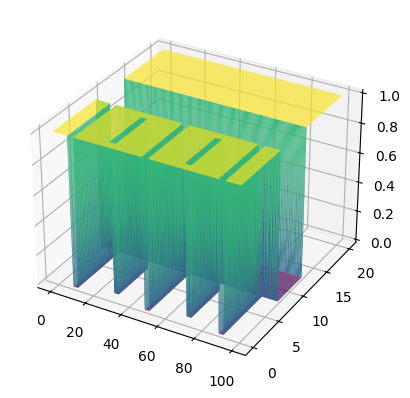

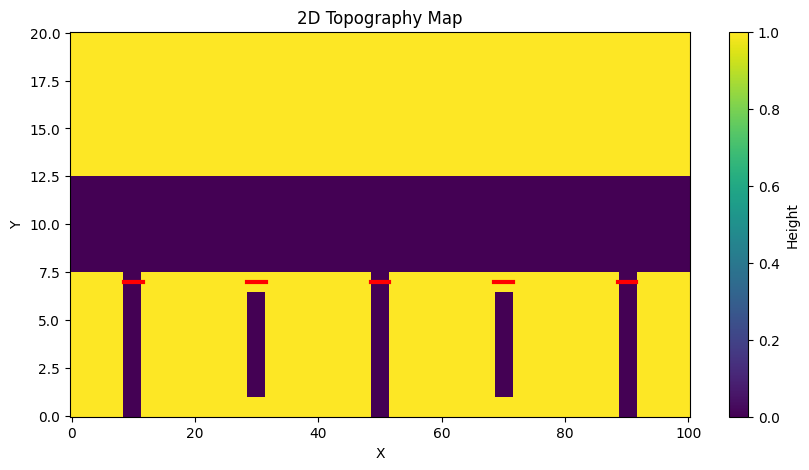

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# 生成测试数据
x = np.linspace(0, env_kwargs["x_max"], 200)
y = np.linspace(0, env_kwargs["y_max"], 200)
X, Y = np.meshgrid(x, y)
X_f, Y_f = X.flatten(), Y.flatten()

Z_f = env_wd.calculate_elevation(X_f, Y_f, **env_kwargs)
gate_loc = env_wd.get_gate_locations(**env_kwargs)

# 绘图
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_trisurf(X_f, Y_f, Z_f, cmap='viridis')
plt.show()

# 1. 将一维数据还原为二维网格矩阵
Z = Z_f.reshape(X.shape)

# 2. 绘图
plt.figure(figsize=(10, 5))
plt.pcolormesh(X, Y, Z, cmap='viridis') # viridis 颜色下，黄色是墙，紫色是路

for i, gate in enumerate(gate_loc):
    # 只有关闭状态 (0) 的路口才画红线
    # if env_kwargs["channel_state"][i] == 0:
    #     # gate 格式为 [(x1, y1), (x2, y2)]
    pts = np.array(gate)
    plt.plot(pts[:, 0], pts[:, 1], color='red', linewidth=3)

# 3. 辅助设置
plt.colorbar(label='Height')
plt.title("2D Topography Map")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

/workspace/Water_Distribution_optimization/test/env_test.sww
Setting omp_num_threads to 1
Figure files for each frame will be stored in _plot


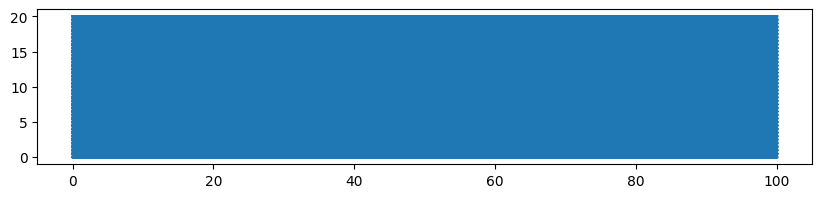

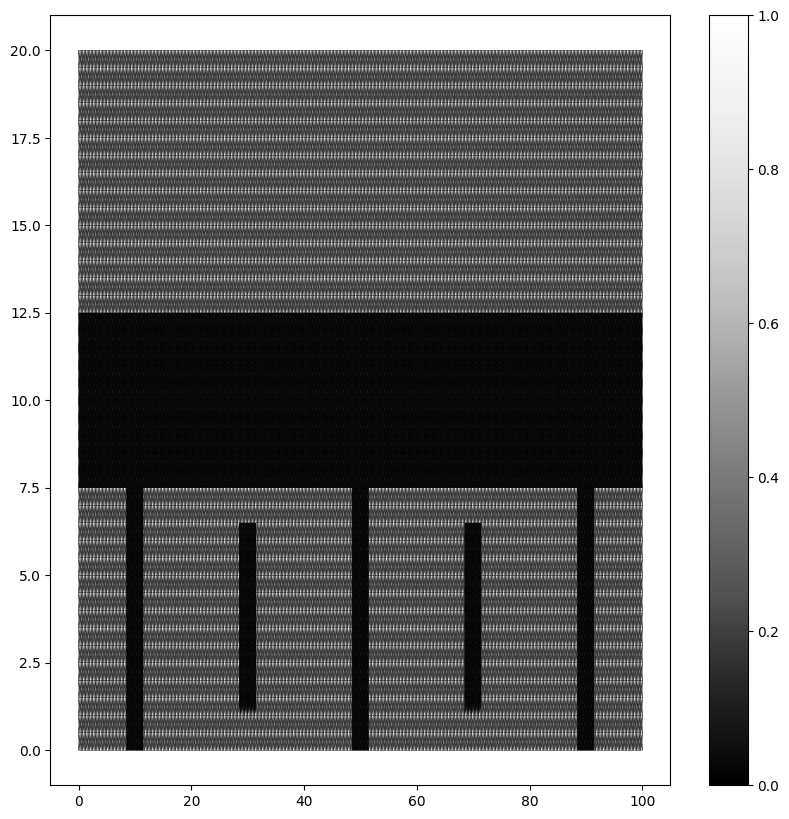

Time = 0.0000 (sec), steps=0 (2s)
Time = 2.0000 (sec), delta t in [0.01119470, 0.01339286] (s), steps=178 (4s)
Time = 4.0000 (sec), delta t in [0.01061746, 0.01123532] (s), steps=180 (4s)
Time = 6.0000 (sec), delta t in [0.00952700, 0.01061027] (s), steps=201 (4s)
Time = 8.0000 (sec), delta t in [0.00930882, 0.00952631] (s), steps=212 (4s)
Time = 10.0000 (sec), delta t in [0.00941455, 0.00951464] (s), steps=212 (4s)
Time = 12.0000 (sec), delta t in [0.00951484, 0.00963626] (s), steps=209 (4s)
Time = 14.0000 (sec), delta t in [0.00961470, 0.00964775] (s), steps=208 (5s)
Time = 16.0000 (sec), delta t in [0.00961120, 0.00961912] (s), steps=209 (5s)
Time = 18.0000 (sec), delta t in [0.00960526, 0.00963327] (s), steps=208 (4s)
Time = 20.0000 (sec), delta t in [0.00961705, 0.00963465] (s), steps=208 (5s)
Time = 22.0000 (sec), delta t in [0.00959924, 0.00963438] (s), steps=208 (5s)
Time = 24.0000 (sec), delta t in [0.00963332, 0.00963824] (s), steps=208 (5s)
Time = 26.0000 (sec), delta t in [

In [4]:
import time

start_time = time.perf_counter()
domain = env_wd.simulation(debug=True)
end_time = time.perf_counter()
duration = end_time - start_time

print(duration)

domain.make_depth_animation()

In [5]:
import time

start_time = time.perf_counter()
water_volums = env_wd.get_water_volum("env_test.sww", gate_loc)
end_time = time.perf_counter()
duration = end_time - start_time

print(duration)

print(water_volums)


95.59771819700109
[np.float64(38.55434240894248), np.float64(0.0), np.float64(28.39737704639412), np.float64(0.0), np.float64(9.222899940178301)]


In [6]:
water_volums

[np.float64(38.55434240894248),
 np.float64(0.0),
 np.float64(28.39737704639412),
 np.float64(0.0),
 np.float64(9.222899940178301)]